## Часть B — Наивный байесовский классификатор и оценка качества
- Строим **классификатор авторов** на публичных текстах (Project Gutenberg)
- Обучаем **Multinomial Naive Bayes** (на counts), сравниваем с **TF-IDF + NB**
- Считаем метрики: accuracy, precision/recall/F1, macro vs micro
- Делаем **domain shift**: обучаем на прозе, тестируем на поэзии (те же авторы)


In [3]:
from pathlib import Path

def read_text_safely(path: Path) -> str:
    for enc in ("utf-8", "utf-8-sig", "cp1251"):
        try:
            return path.read_text(encoding=enc)
        except UnicodeDecodeError:
            pass

    return path.read_bytes().decode("utf-8", errors="replace")

files = {
    "Carsky": Path("Carsky_blitzkrig_Bozhe_hrani_popadanza_German_Romanov.txt"),
    "Kruz":  Path("Kruz_Zemlya_lischnih.txt"),
}

texts = {a: read_text_safely(p) for a, p in files.items()}
{a: len(t) for a, t in texts.items()}


{'Carsky': 411522, 'Kruz': 894776}

In [4]:
import re

TOKEN_RE = re.compile(r"[А-Яа-яЁё]+(?:-[А-Яа-яЁё]+)*|\d+", re.UNICODE)

def simple_tokenize(text: str):
    return TOKEN_RE.findall(text.lower())

def chunk_tokens(tokens, chunk_size=200, min_size=80, stride=None):
    if stride is None:
        stride = chunk_size
    out = []
    for i in range(0, len(tokens), stride):
        ch = tokens[i:i+chunk_size]
        if len(ch) >= min_size:
            out.append(ch)
    return out

def make_chunks(docs, domain_filter):
    X, y, groups = [], [], []
    for d in docs:
        if d["domain"] != domain_filter:
            continue
        toks = simple_tokenize(d["text"])
        for ch in chunk_tokens(toks, chunk_size=200, min_size=80):
            X.append(" ".join(ch)) 
            y.append(d["author"])
            groups.append(d["doc_id"])
    return X, y, groups

In [5]:
def make_in_domain_chunks(text_by_author, chunk_size=200, min_size=80, train_ratio=0.7):
    X_train, y_train, X_test, y_test = [], [], [], []
    for author, text in text_by_author.items():
        toks = simple_tokenize(text)
        cut = int(len(toks) * train_ratio)

        train_toks = toks[:cut]
        test_toks  = toks[cut:]

        for ch in chunk_tokens(train_toks, chunk_size=chunk_size, min_size=min_size):
            X_train.append(" ".join(ch))
            y_train.append(author)

        for ch in chunk_tokens(test_toks, chunk_size=chunk_size, min_size=min_size):
            X_test.append(" ".join(ch))
            y_test.append(author)

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = make_in_domain_chunks(texts, chunk_size=200, min_size=80)
len(X_train), len(X_test), set(y_train), set(y_test)


(650, 279, {'Carsky', 'Kruz'}, {'Carsky', 'Kruz'})

chunks: 630 259 {'Carsky', 'Kruz'} {'Carsky', 'Kruz'}
              precision    recall  f1-score   support

      Carsky      0.985     0.800     0.883        80
        Kruz      0.918     0.994     0.954       179

    accuracy                          0.934       259
   macro avg      0.951     0.897     0.919       259
weighted avg      0.938     0.934     0.932       259



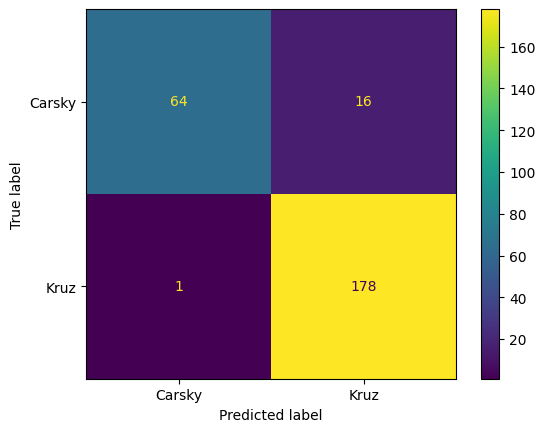

Carsky >> Kruz:
петр                  5.393
константин            4.481
король                4.094
ибо                   4.037
петрович              4.007
посол                 3.945
императорское         3.912
император             3.878
армфельт              3.843
константинополь       3.843
чтоб                  3.806
короля                3.806
граф                  3.806
фельдмаршал           3.806
царевич               3.769
высочество            3.769
императора            3.729
грейг                 3.646
отнюдь                3.602
князь                 3.602

Kruz >> Carsky:
пилар                 4.431
немцов                4.153
поэтому               3.908
конвой                3.709
зимин                 3.633
территория            3.550
барабанов             3.497
общем                 3.460
затем                 3.460
машину                3.441
владимирский          3.421
5                     3.381
джо                   3.318
рукой                 3.178
порто-франко   

In [10]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np

def chunk_tokens(tokens, chunk_size=200, min_size=80):
    out = []
    for i in range(0, len(tokens), chunk_size):
        ch = tokens[i:i+chunk_size]
        if len(ch) >= min_size:
            out.append(ch)
    return out

def make_train_test_chunks(text_by_author, train_ratio=0.7, chunk_size=200, min_size=80, gap_tokens=2000):
    X_train, y_train, X_test, y_test = [], [], [], []
    for author, text in text_by_author.items():
        toks = simple_tokenize(text)
        cut = int(len(toks) * train_ratio)

        train_end = max(0, cut - gap_tokens)
        test_start = min(len(toks), cut + gap_tokens)

        for ch in chunk_tokens(toks[:train_end], chunk_size, min_size):
            X_train.append(" ".join(ch)); y_train.append(author)

        for ch in chunk_tokens(toks[test_start:], chunk_size, min_size):
            X_test.append(" ".join(ch)); y_test.append(author)

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = make_train_test_chunks(texts, train_ratio=0.7)

print("chunks:", len(X_train), len(X_test), set(y_train), set(y_test))

vectorizer = CountVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    lowercase=False,
    token_pattern=None
)

Xtr = vectorizer.fit_transform(X_train)
Xte = vectorizer.transform(X_test)

clf = MultinomialNB(alpha=1.0)
clf.fit(Xtr, y_train)
pred = clf.predict(Xte)

print(classification_report(y_test, pred, digits=3))
ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=clf.classes_)
plt.show()

feature_names = vectorizer.get_feature_names_out()
classes = list(clf.classes_)
iA = classes.index("Carsky")
iB = classes.index("Kruz")

delta = clf.feature_log_prob_[iA] - clf.feature_log_prob_[iB]
topA = np.argsort(delta)[::-1][:20]
topB = np.argsort(delta)[:20]

print("Carsky >> Kruz:")
for j in topA:
    print(f"{feature_names[j]:20s}  {delta[j]:.3f}")

print("\nKruz >> Carsky:")
for j in topB:
    print(f"{feature_names[j]:20s}  {(-delta[j]):.3f}")

In [14]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np

def train_eval_show(X_train, y_train, X_test, y_test, vectorizer, alpha=1.0, top_k=20):
    Xtr = vectorizer.fit_transform(X_train)
    Xte = vectorizer.transform(X_test)

    clf = MultinomialNB(alpha=alpha).fit(Xtr, y_train)
    pred = clf.predict(Xte)

    print(classification_report(y_test, pred, digits=3))
    ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=clf.classes_)
    plt.show()

    feature_names = vectorizer.get_feature_names_out()
    classes = list(clf.classes_)
    iA = classes.index("Carsky")
    iB = classes.index("Kruz")

    delta = clf.feature_log_prob_[iA] - clf.feature_log_prob_[iB]
    topA = np.argsort(delta)[::-1][:top_k]
    topB = np.argsort(delta)[:top_k]

    print("Carsky >> Kruz:")
    for j in topA:
        print(f"{feature_names[j]:20s}  {delta[j]:.3f}")
    print("\nKruz >> Carsky:")
    for j in topB:
        print(f"{feature_names[j]:20s}  {(-delta[j]):.3f}")

    return clf




## n-граммы

              precision    recall  f1-score   support

      Carsky      0.986     0.900     0.941        80
        Kruz      0.957     0.994     0.975       179

    accuracy                          0.965       259
   macro avg      0.972     0.947     0.958       259
weighted avg      0.966     0.965     0.965       259



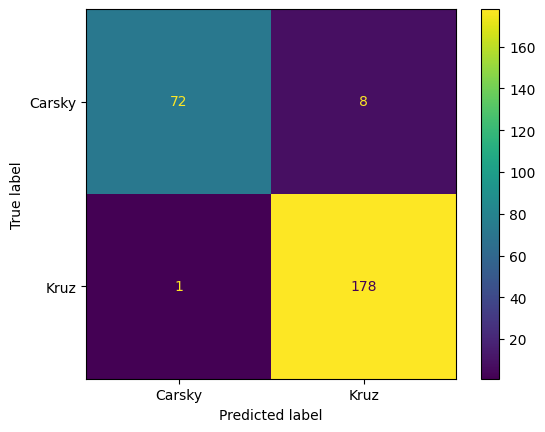

Carsky >> Kruz:
петр                  5.531
константин            4.619
король                4.232
ибо                   4.175
петрович              4.145
посол                 4.083
императорское         4.050
вот только            4.050
император             4.016
константинополь       3.981
армфельт              3.981
короля                3.944
фельдмаршал           3.944
чтоб                  3.944
граф                  3.944
ваше императорское    3.907
царевич               3.907
высочество            3.907
константин петрович   3.867
императора            3.867

Kruz >> Carsky:
пилар                 4.293
немцов                4.015
мария пилар           3.926
поэтому               3.770
конвой                3.571
зимин                 3.495
территория            3.412
барабанов             3.359
в общем               3.322
общем                 3.322
затем                 3.322
машину                3.303
владимирский          3.283
5                     3.243
спросил я      

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [15]:
vec_bg = CountVectorizer(
    tokenizer=str.split, preprocessor=None, lowercase=False, token_pattern=None,
    ngram_range=(1,2), min_df=2
)
train_eval_show(X_train, y_train, X_test, y_test, vec_bg)

## стоп-слова

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


              precision    recall  f1-score   support

      Carsky      0.986     0.850     0.913        80
        Kruz      0.937     0.994     0.965       179

    accuracy                          0.950       259
   macro avg      0.961     0.922     0.939       259
weighted avg      0.952     0.950     0.949       259



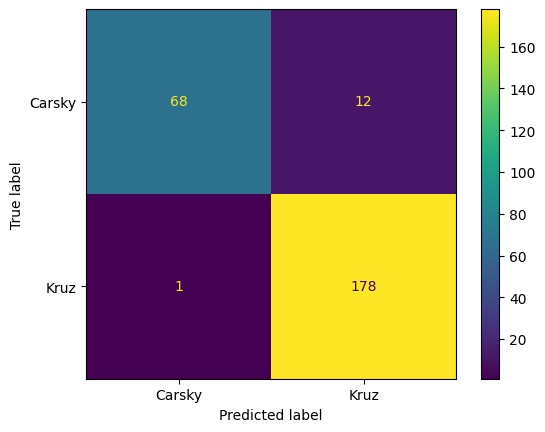

Carsky >> Kruz:
петр                  5.286
константин            4.374
король                3.987
ибо                   3.930
петрович              3.900
посол                 3.837
императорское         3.805
император             3.771
армфельт              3.736
константинополь       3.736
фельдмаршал           3.699
короля                3.699
граф                  3.699
высочество            3.662
царевич               3.662
императора            3.622
грейг                 3.539
отнюдь                3.494
князь                 3.494
суворов               3.448

Kruz >> Carsky:
пилар                 4.538
немцов                4.260
поэтому               4.015
конвой                3.816
зимин                 3.740
территория            3.657
барабанов             3.604
общем                 3.567
затем                 3.567
машину                3.548
владимирский          3.528
5                     3.488
джо                   3.425
рукой                 3.285
мной           

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [16]:
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords

RU_STOP = set(stopwords.words("russian"))

vec_sw = CountVectorizer(
    tokenizer=str.split, preprocessor=None, lowercase=False, token_pattern=None,
    stop_words=list(RU_STOP)
)
train_eval_show(X_train, y_train, X_test, y_test, vec_sw)

## Лемматизация

              precision    recall  f1-score   support

      Carsky      0.986     0.912     0.948        80
        Kruz      0.962     0.994     0.978       179

    accuracy                          0.969       259
   macro avg      0.974     0.953     0.963       259
weighted avg      0.970     0.969     0.969       259



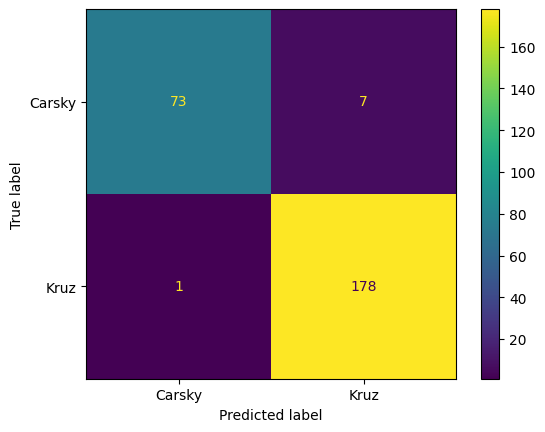

Carsky >> Kruz:
пётр                  5.660
король                4.999
император             4.836
константин            4.776
казак                 4.606
петрович              4.509
фельдмаршал           4.424
царевич               4.401
константинополь       4.401
князь                 4.355
императорский         4.330
осман                 4.330
посол                 4.306
армфельт              4.280
адмирал               4.255
ибо                   4.143
суворов               4.113
генерал               4.113
грейг                 4.113
султан                4.051

Kruz >> Carsky:
пилар                 4.325
немцов                4.251
поэтому               3.802
зимин                 3.687
владимирский          3.646
лукас                 3.408
затем                 3.353
засада                3.334
5                     3.275
стойка                3.254
банда                 3.233
джо                   3.212
игорь                 3.190
боец                  3.167
территория     

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [17]:
import pymorphy3
from functools import lru_cache

morph = pymorphy3.MorphAnalyzer()

@lru_cache(maxsize=200_000)
def lemma(w: str) -> str:
    if w.isdigit():
        return w
    return morph.parse(w)[0].normal_form

def lemmatize_space_text(space_text: str) -> str:
    return " ".join(lemma(t) for t in space_text.split())

X_train_lem = [lemmatize_space_text(t) for t in X_train]
X_test_lem  = [lemmatize_space_text(t) for t in X_test]

vec_lem = CountVectorizer(
    tokenizer=str.split, preprocessor=None, lowercase=False, token_pattern=None
)
train_eval_show(X_train_lem, y_train, X_test_lem, y_test, vec_lem)

              precision    recall  f1-score   support

      Carsky      0.987     0.950     0.968        80
        Kruz      0.978     0.994     0.986       179

    accuracy                          0.981       259
   macro avg      0.983     0.972     0.977       259
weighted avg      0.981     0.981     0.981       259



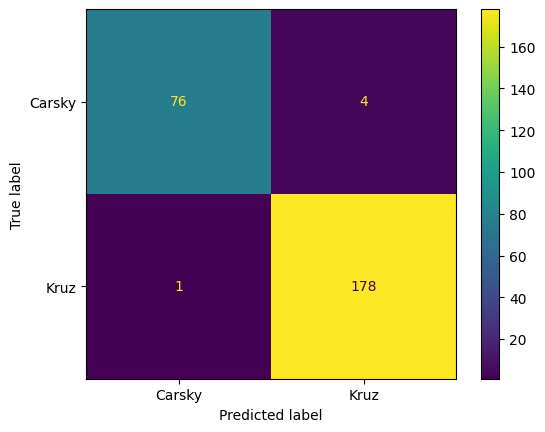

Carsky >> Kruz:
пётр                  5.699
король                5.038
император             4.875
константин            4.815
казак                 4.645
петрович              4.548
фельдмаршал           4.463
константинополь       4.440
царевич               4.440
князь                 4.394
осман                 4.369
императорский         4.369
посол                 4.345
армфельт              4.319
адмирал               4.293
ибо                   4.182
грейг                 4.152
генерал               4.152
суворов               4.152
султан                4.090

Kruz >> Carsky:
пилар                 4.286
мария пилар           4.279
немцов                4.212
поэтому               3.763
зимин                 3.648
владимирский          3.607
лукас                 3.369
в общий               3.351
спросить я            3.351
затем                 3.314
засада                3.295
5                     3.236
стойка                3.215
банда                 3.194
джо            

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [18]:
vec_lem_bg = CountVectorizer(
    tokenizer=str.split, preprocessor=None, lowercase=False, token_pattern=None,
    ngram_range=(1,2), min_df=2
)
train_eval_show(X_train_lem, y_train, X_test_lem, y_test, vec_lem_bg)

## разделение текста на повествование и диалог

In [19]:
def split_dialogue_narration(raw: str):
    lines = raw.splitlines()
    dlg, nar = [], []
    for line in lines:
        s = line.strip()
        if not s:
            continue
        if s.startswith(("—", "-", "–")):
            dlg.append(s)
        else:
            nar.append(s)
    return "\n".join(nar), "\n".join(dlg)

texts_nar = {}
texts_dlg = {}
for a, t in texts.items():
    nar, dlg = split_dialogue_narration(t)
    texts_nar[a] = nar
    texts_dlg[a] = dlg

# sanity-check: токенов в каждом домене
{a: (len(simple_tokenize(texts_nar[a])), len(simple_tokenize(texts_dlg[a]))) for a in texts}

{'Carsky': (43098, 16662), 'Kruz': (111183, 14791)}

shift chunks: 157 labels: {'Carsky', 'Kruz'}
SHIFT (dialogues) report:
              precision    recall  f1-score   support

      Carsky      1.000     0.386     0.557        83
        Kruz      0.592     1.000     0.744        74

    accuracy                          0.675       157
   macro avg      0.796     0.693     0.650       157
weighted avg      0.808     0.675     0.645       157



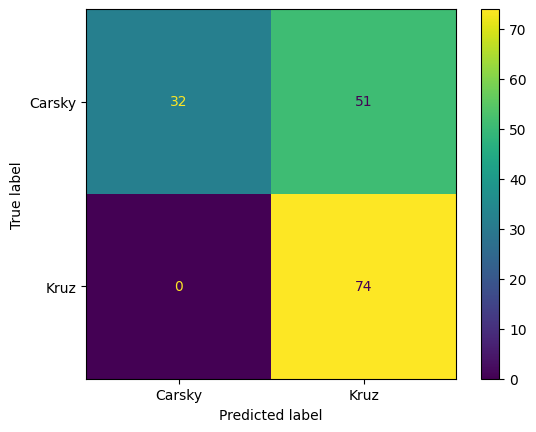

In [20]:
X_train_n, y_train_n, X_test_n, y_test_n = make_train_test_chunks(texts_nar, train_ratio=0.7)

def make_all_chunks(text_by_author, chunk_size=200, min_size=80):
    X, y = [], []
    for author, text in text_by_author.items():
        toks = simple_tokenize(text)
        for ch in chunk_tokens(toks, chunk_size=chunk_size, min_size=min_size):
            X.append(" ".join(ch)); y.append(author)
    return X, y

X_shift, y_shift = make_all_chunks(texts_dlg, chunk_size=200, min_size=80)

print("shift chunks:", len(X_shift), "labels:", set(y_shift))

vec_base = CountVectorizer(tokenizer=str.split, preprocessor=None, lowercase=False, token_pattern=None)

# учим на narration train
Xtr = vec_base.fit_transform(X_train_n)
clf = MultinomialNB(alpha=1.0).fit(Xtr, y_train_n)

# тестируем на dialogues
pred_shift = clf.predict(vec_base.transform(X_shift))

print("SHIFT (dialogues) report:")
print(classification_report(y_shift, pred_shift, digits=3))
ConfusionMatrixDisplay.from_predictions(y_shift, pred_shift, labels=clf.classes_)
plt.show()